# vR.P.0 — Image Tampering Detection and Localization
## Pretrained ResNet-34 UNet Baseline

---

| Field | Value |
|-------|-------|
| **Version** | vR.P.0 |
| **Track** | Pretrained Localization (Track 2) |
| **Architecture** | UNet with ResNet-34 encoder (ImageNet pretrained) |
| **Change** | First pretrained experiment — frozen encoder, RGB input, BCEDiceLoss |
| **Parent** | New track (informed by ETASR ablation study vR.1.x) |
| **Dataset** | CASIA v2.0 (~12,614 images) |
| **Platform** | Kaggle (T4/P100 GPU) |
| **Framework** | PyTorch + Segmentation Models PyTorch (SMP) |

---

### Pipeline Overview

```
Raw RGB Image (384x384)
    |
    v
ImageNet Normalization (mean/std)
    |
    v
ResNet-34 Encoder (FROZEN — ImageNet weights)
    |  [skip connections at 4 resolutions]
    v
UNet Decoder (TRAINABLE — ~500K params)
    |
    v
Sigmoid → 384x384 Binary Mask (pixel-level tampered probability)
    |
    v
Metrics: Pixel F1, IoU, Dice, AUC + Classification Accuracy
```

### Why Pretrained? Why Now?

The ETASR ablation study (vR.1.x track) showed:
- **vR.1.1 baseline:** 88.38% classification accuracy, but **no localization capability**
- **vR.1.2 augmentation:** REJECTED (-2.85pp regression)
- **Assignment requirement:** Pixel-level tampered region masks — impossible with ETASR CNN

The pretrained approach addresses this fundamental limitation:
- **ResNet-34 (ImageNet)** provides rich visual features without training from scratch
- **UNet decoder** produces pixel-level segmentation masks
- **v6.5 proved this works:** Tam-F1 = 0.41 with the same encoder

This notebook establishes the pretrained localization baseline.

---

## Change Log

| Version | Track | Change | Result |
|---------|-------|--------|--------|
| vR.1.0 | ETASR | Paper reproduction baseline | 89.89% val acc |
| vR.1.1 | ETASR | Proper test split + metrics | 88.38% test acc, AUC=0.9601 |
| vR.1.2 | ETASR | Data augmentation | **REJECTED** (-2.85pp) |
| vR.1.3 | ETASR | Class weights | Pending |
| **vR.P.0** | **Pretrained** | **ResNet-34 UNet, frozen encoder, RGB input** | **This notebook** |

### What Changed from ETASR Track

| Aspect | ETASR (vR.1.x) | Pretrained (vR.P.0) |
|--------|----------------|---------------------|
| Framework | TensorFlow/Keras | **PyTorch + SMP** |
| Input | ELA maps (128x128) | **RGB images (384x384)** |
| Architecture | 2-layer CNN (29.5M params) | **UNet + ResNet-34 (~500K trainable)** |
| Output | Binary class label | **384x384 pixel mask** |
| Encoder | From scratch | **ImageNet pretrained (frozen)** |
| Loss | Categorical crossentropy | **BCEDiceLoss** |
| Localization | Impossible | **Native** |

In [1]:
# ============================================================
# 1. SETUP
# ============================================================

# Install segmentation-models-pytorch
!pip install -q segmentation-models-pytorch
!pip install -q wandb

import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageChops, ImageEnhance
from io import BytesIO
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# ============================================================
# Configuration
# ============================================================
VERSION = 'vR.P.0'
CHANGE = 'ResNet34 UNet baseline — frozen encoder, RGB input, BCEDiceLoss'
SEED = 42
IMAGE_SIZE = 384
BATCH_SIZE = 16
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
IN_CHANNELS = 3
NUM_CLASSES = 1
LEARNING_RATE = 1e-3
EPOCHS = 25
PATIENCE = 7
NUM_WORKERS = 0  # 0 = main process only (avoids multiprocessing bugs on Kaggle)
CHECKPOINT_PATH = f'{VERSION}_checkpoint.pth'
# --- Kaggle Persistence: Files only ---
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
RESULTS_DIR = '/kaggle/working/results'
LOGS_DIR = '/kaggle/working/logs'
for _d in [CHECKPOINT_DIR, RESULTS_DIR, LOGS_DIR]:
    os.makedirs(_d, exist_ok=True)
RESUME = True  # Kaggle persistence: auto-resume from checkpoints
LATEST_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.pt')
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'best_model.pt')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility

# --- Weights & Biases Experiment Tracking ---
USE_WANDB = True
WANDB_PROJECT = 'Tampered Image Detection & Localization'
DATASET_NAME = 'CASIA2'

import re as _re
_nb_dir = os.path.basename(os.getcwd()).lower()
_run_match = _re.search(r'run-(\d+)', _nb_dir)
RUN_ID = f'run{_run_match.group(1)}' if _run_match else 'run01'
EXPERIMENT_ID = VERSION.lower().replace('.', '').replace(' ', '')

# Infer feature flags from notebook config
_change_lower = CHANGE.lower()
_input_lower = globals().get('INPUT_TYPE', '').lower()
FEATURE_SET = 'rgb'
if 'multi-q' in _input_lower or 'multi-quality' in _change_lower:
    FEATURE_SET = 'multi_quality_ela'
elif 'ela' in _change_lower or 'ela' in _input_lower:
    FEATURE_SET = 'ela'
if 'dct' in _input_lower:
    FEATURE_SET = 'dct' if FEATURE_SET == 'rgb' else f'{FEATURE_SET}+dct'
if 'srm' in _input_lower:
    FEATURE_SET = 'srm_noise'
if 'ycbcr' in _input_lower:
    FEATURE_SET = 'ycbcr'
if 'noiseprint' in _input_lower:
    FEATURE_SET = 'noiseprint'
USE_TTA = 'tta' in _change_lower
JPEG_AUG = 'jpeg' in _change_lower and 'augment' in _change_lower
EDGE_SUPERVISION = 'edge' in _change_lower
NOISE_FEATURES = 'noise' in _input_lower or 'srm' in _input_lower

if USE_WANDB:
    try:
        import wandb
        # Kaggle Secrets first, then interactive fallback
        try:
            from kaggle_secrets import UserSecretsClient
            _key = UserSecretsClient().get_secret("WANDB_API_KEY")
            wandb.login(key=_key)
        except Exception:
            wandb.login()
        wandb.init(
            project=WANDB_PROJECT,
            name=VERSION,
            config={
                'experiment': EXPERIMENT_ID, 'version': VERSION, 'change': CHANGE,
                'run': RUN_ID, 'dataset': DATASET_NAME, 'feature_set': FEATURE_SET,
                'input_type': globals().get('INPUT_TYPE', FEATURE_SET),
                'tta': USE_TTA, 'jpeg_aug': JPEG_AUG,
                'edge_supervision': EDGE_SUPERVISION, 'noise_features': NOISE_FEATURES,
                'encoder': ENCODER, 'in_channels': IN_CHANNELS,
                'img_size': IMG_SIZE, 'batch_size': BATCH_SIZE,
                'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'patience': PATIENCE,
            },
            reinit=True,
        )
        print(f'W&B run initialized: {EXPERIMENT_ID}_{RUN_ID}')
    except Exception as e:
        print(f'W&B init failed ({e}), continuing without tracking')
        USE_WANDB = False

print(f'Experiment: {EXPERIMENT_ID} | Run: {RUN_ID} | Features: {FEATURE_SET}')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# GPU info
print(f"{'='*60}")
print(f"  {VERSION} — {CHANGE}")
print(f"{'='*60}")
print(f"Device:   {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU:      {torch.cuda.get_device_name(0)}")
    print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch:  {torch.__version__}")
print(f"SMP:      {smp.__version__}")
print(f"Image:    {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Encoder:  {ENCODER} ({ENCODER_WEIGHTS})")
print(f"Batch:    {BATCH_SIZE}")
print(f"LR:       {LEARNING_RATE}")
print(f"Epochs:   {EPOCHS}")
print(f"Patience: {PATIENCE}")
print(f"Seed:     {SEED}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:00
W&B init failed (No API key configured. Use `wandb login` to log in.), continuing without tracking
Experiment: vrp0 | Run: run01 | Features: rgb
  vR.P.0 — ResNet34 UNet baseline — frozen encoder, RGB input, BCEDiceLoss
Device:   cuda
GPU:      Tesla P100-PCIE-16GB
VRAM:     17.1 GB
PyTorch:  2.9.0+cu126
SMP:      0.5.0
Image:    384x384
Encoder:  resnet34 (imagenet)
Batch:    16
LR:       0.001
Epochs:   25
Patience: 7
Seed:     42


---

## 2. Dataset

### CASIA v2.0

The CASIA v2.0 dataset contains ~12,614 images:
- **Authentic (Au):** ~7,491 images — unmodified photographs
- **Tampered (Tp):** ~5,123 images — images with splicing or copy-move forgery

For **localization**, we need pixel-level ground truth masks indicating which regions are tampered. CASIA v2.0 includes ground truth masks for tampered images. If GT masks are not available in the Kaggle dataset, we generate pseudo-masks using ELA thresholding as a fallback.

For **authentic images**, the ground truth mask is all zeros (no tampering).

In [2]:
# ============================================================
# 2.1 Dataset Path Discovery
# ============================================================

def find_dataset():
    """Search /kaggle/input/ for Au/ and Tp/ directories."""
    search_roots = ['/kaggle/input', '/content/drive/MyDrive']
    for base in search_roots:
        if not os.path.isdir(base):
            continue
        for dirpath, dirnames, _ in os.walk(base):
            if 'Au' in dirnames and 'Tp' in dirnames:
                return dirpath, os.path.join(dirpath, 'Au'), os.path.join(dirpath, 'Tp')
    return None, None, None

DATASET_ROOT, AU_DIR, TP_DIR = find_dataset()

if DATASET_ROOT is None:
    for base in ['/kaggle/input']:
        if os.path.isdir(base):
            print(f'Contents of {base}:')
            for dirpath, dirnames, filenames in os.walk(base):
                depth = dirpath.replace(base, '').count(os.sep)
                print(f'{"  " * depth}{os.path.basename(dirpath)}/')
                if depth >= 2:
                    break
    raise FileNotFoundError('Could not find Au/ and Tp/ directories.')

# Search for ground truth mask directory
GT_DIR = None
gt_search_patterns = ['groundtruth', 'gt', 'mask', 'ground_truth', 'Gt']

# Check within dataset root
for root, dirs, files in os.walk(os.path.dirname(DATASET_ROOT)):
    for d in dirs:
        if any(pat in d.lower() for pat in ['groundtruth', 'gt', 'mask']):
            candidate = os.path.join(root, d)
            if any(Path(f).suffix.lower() in {'.jpg','.jpeg','.png','.tif','.bmp'}
                   for f in os.listdir(candidate) if os.path.isfile(os.path.join(candidate, f))):
                GT_DIR = candidate
                break
    if GT_DIR:
        break

# Check separate Kaggle datasets
if GT_DIR is None:
    input_dir = '/kaggle/input'
    if os.path.isdir(input_dir):
        for d in sorted(os.listdir(input_dir)):
            if any(pat in d.lower() for pat in ['groundtruth', 'gt', 'mask']):
                for root, dirs, files in os.walk(os.path.join(input_dir, d)):
                    img_files = [f for f in files if Path(f).suffix.lower() in {'.jpg','.jpeg','.png','.tif','.bmp'}]
                    if img_files:
                        GT_DIR = root
                        break
                if GT_DIR:
                    break

SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

print(f'Dataset root:  {DATASET_ROOT}')
print(f'Authentic dir: {AU_DIR}  ({len(os.listdir(AU_DIR))} files)')
print(f'Tampered dir:  {TP_DIR}  ({len(os.listdir(TP_DIR))} files)')
print(f'GT mask dir:   {GT_DIR}' if GT_DIR else 'GT mask dir:   NOT FOUND — will generate pseudo-masks from ELA')

Dataset root:  /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK
Authentic dir: /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK/Au  (7491 files)
Tampered dir:  /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK/Tp  (5123 files)
GT mask dir:   NOT FOUND — will generate pseudo-masks from ELA


In [3]:
# ============================================================
# 2.2 Collect Image Paths and Ground Truth Masks
# ============================================================

def collect_paths(directory):
    """Collect sorted image paths from a directory."""
    paths = []
    for f in sorted(os.listdir(directory)):
        if Path(f).suffix.lower() in SUPPORTED_EXTENSIONS:
            paths.append(os.path.join(directory, f))
    return paths

au_paths = collect_paths(AU_DIR)
tp_paths = collect_paths(TP_DIR)

# Build GT mask lookup (stem -> path)
gt_map = {}
if GT_DIR:
    for f in sorted(os.listdir(GT_DIR)):
        if Path(f).suffix.lower() in SUPPORTED_EXTENSIONS:
            stem = Path(f).stem.lower()
            gt_map[stem] = os.path.join(GT_DIR, f)
    print(f'GT masks available: {len(gt_map)}')

# Match tampered images to GT masks
tp_with_gt = 0
tp_without_gt = 0
for tp in tp_paths:
    stem = Path(tp).stem.lower()
    # Try exact match, and common variants
    variants = [stem, stem + '_gt', stem.replace('tp', 'gt'), stem.replace('Tp', 'Gt')]
    found = any(v in gt_map for v in variants)
    if found:
        tp_with_gt += 1
    else:
        tp_without_gt += 1

USE_GT_MASKS = GT_DIR is not None and tp_with_gt > len(tp_paths) * 0.5

print(f'\nAuthentic images:  {len(au_paths)}')
print(f'Tampered images:   {len(tp_paths)}')
print(f'Total:             {len(au_paths) + len(tp_paths)}')
print(f'Class ratio (Au:Tp): {len(au_paths)/len(tp_paths):.2f}:1')
if GT_DIR:
    print(f'\nTampered with GT mask:    {tp_with_gt}')
    print(f'Tampered without GT mask: {tp_without_gt}')
print(f'\nUsing GT masks: {USE_GT_MASKS}')
if not USE_GT_MASKS:
    print('  -> Will generate pseudo-masks from ELA thresholding')


Authentic images:  7491
Tampered images:   5123
Total:             12614
Class ratio (Au:Tp): 1.46:1

Using GT masks: False
  -> Will generate pseudo-masks from ELA thresholding


In [4]:
# ============================================================
# 2.3 ELA Pseudo-Mask Generation (Fallback)
# ============================================================

def compute_ela(image_path, quality=90):
    """Compute Error Level Analysis map."""
    original = Image.open(image_path).convert('RGB')
    buffer = BytesIO()
    original.save(buffer, 'JPEG', quality=quality)
    buffer.seek(0)
    resaved = Image.open(buffer)
    ela = ImageChops.difference(original, resaved)
    extrema = ela.getextrema()
    max_diff = max(val[1] for val in extrema)
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    ela = ImageEnhance.Brightness(ela).enhance(scale)
    return ela

def generate_pseudo_mask(image_path, quality=90, threshold=50):
    """Generate a binary pseudo-mask from ELA.
    Pixels with ELA brightness above threshold are marked as tampered.
    """
    ela = compute_ela(image_path, quality)
    ela_gray = np.array(ela.convert('L'))
    # Adaptive threshold: use mean + 2*std of the ELA map
    mean_val = ela_gray.mean()
    std_val = ela_gray.std()
    adaptive_thresh = max(threshold, mean_val + 2 * std_val)
    mask = (ela_gray > adaptive_thresh).astype(np.float32)
    return mask

def get_gt_mask(image_path, target_size):
    """Get ground truth mask for an image.
    - Authentic images: all-zero mask
    - Tampered images: GT mask if available, else ELA pseudo-mask
    """
    is_tampered = '/Tp/' in image_path or '\\Tp\\' in image_path

    if not is_tampered:
        # Authentic — all zeros (no tampering)
        return np.zeros((target_size, target_size), dtype=np.float32)

    if USE_GT_MASKS:
        # Try to find matching GT mask
        stem = Path(image_path).stem.lower()
        variants = [stem, stem + '_gt', stem.replace('tp', 'gt'), stem.replace('Tp', 'Gt')]
        for v in variants:
            if v in gt_map:
                mask = Image.open(gt_map[v]).convert('L')
                mask = mask.resize((target_size, target_size), Image.NEAREST)
                mask_arr = np.array(mask, dtype=np.float32)
                # Normalize to [0, 1]
                if mask_arr.max() > 1:
                    mask_arr = mask_arr / 255.0
                # Binarize
                mask_arr = (mask_arr > 0.5).astype(np.float32)
                return mask_arr

    # Fallback: ELA pseudo-mask
    try:
        mask = generate_pseudo_mask(image_path)
        mask_pil = Image.fromarray((mask * 255).astype(np.uint8))
        mask_pil = mask_pil.resize((target_size, target_size), Image.NEAREST)
        return np.array(mask_pil, dtype=np.float32) / 255.0
    except Exception:
        return np.zeros((target_size, target_size), dtype=np.float32)

# Quick test
test_au = au_paths[0]
test_tp = tp_paths[0]
mask_au = get_gt_mask(test_au, IMAGE_SIZE)
mask_tp = get_gt_mask(test_tp, IMAGE_SIZE)
print(f'Authentic mask — shape: {mask_au.shape}, sum: {mask_au.sum():.0f} (should be 0)')
print(f'Tampered mask  — shape: {mask_tp.shape}, sum: {mask_tp.sum():.0f} (should be > 0)')

Authentic mask — shape: (384, 384), sum: 0 (should be 0)
Tampered mask  — shape: (384, 384), sum: 1318 (should be > 0)


---

## 3. Data Preparation

### Input Pipeline

| Aspect | Value |
|--------|-------|
| Input format | RGB images |
| Resolution | 384x384 |
| Normalization | ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) |
| Masks | Binary (0 = authentic, 1 = tampered) |
| Split | 70/15/15 (train/val/test), stratified, seed=42 |
| DataLoader | batch_size=16, shuffle=True (train) |

### Why RGB (Not ELA)?

ImageNet pretrained features transfer best when the input distribution matches ImageNet:
- **RGB images** have the same statistical properties as ImageNet → excellent feature transfer
- **ELA maps** have fundamentally different statistics (BatchNorm domain shift) → partial transfer
- **v6.5** achieved Tam-F1 = 0.41 with RGB + pretrained → proven approach

ELA input will be tested as an ablation in vR.P.2.

In [5]:
# ============================================================
# 3.1 PyTorch Dataset and Transforms
# ============================================================

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class CASIASegmentationDataset(Dataset):
    """CASIA v2.0 dataset for tampered region segmentation.

    Each item returns:
        image:  (3, H, W) tensor — ImageNet-normalized RGB
        mask:   (1, H, W) tensor — binary mask (0=authentic, 1=tampered)
        label:  int — 0 (authentic) or 1 (tampered)
    """

    def __init__(self, image_paths, labels, transform=None, mask_size=384):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.mask_size = mask_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        # Load image
        try:
            image = Image.open(path).convert('RGB')
        except Exception:
            # Return a blank if image fails to load
            image = Image.new('RGB', (self.mask_size, self.mask_size), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        # Get mask
        mask = get_gt_mask(path, self.mask_size)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)  # (1, H, W)

        return image, mask, label

print(f'Dataset class ready.')
print(f'Image transform: Resize({IMAGE_SIZE}) -> ToTensor -> Normalize(ImageNet)')

Dataset class ready.
Image transform: Resize(384) -> ToTensor -> Normalize(ImageNet)


In [6]:
# ============================================================
# 3.2 Data Splitting (70/15/15 Stratified)
# ============================================================

# Combine paths and labels
all_paths = au_paths + tp_paths
all_labels = [0] * len(au_paths) + [1] * len(tp_paths)

# First split: 70% train, 30% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)

# Second split: 50/50 of temp -> 15% val, 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

# Create datasets
train_dataset = CASIASegmentationDataset(train_paths, train_labels, transform=image_transform, mask_size=IMAGE_SIZE)
val_dataset = CASIASegmentationDataset(val_paths, val_labels, transform=image_transform, mask_size=IMAGE_SIZE)
test_dataset = CASIASegmentationDataset(test_paths, test_labels, transform=image_transform, mask_size=IMAGE_SIZE)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Print split info
print(f'Train: {len(train_dataset):>6} images  (Au: {sum(1 for l in train_labels if l==0)}, Tp: {sum(1 for l in train_labels if l==1)})')
print(f'Val:   {len(val_dataset):>6} images  (Au: {sum(1 for l in val_labels if l==0)}, Tp: {sum(1 for l in val_labels if l==1)})')
print(f'Test:  {len(test_dataset):>6} images  (Au: {sum(1 for l in test_labels if l==0)}, Tp: {sum(1 for l in test_labels if l==1)})')
print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train:   8829 images  (Au: 5243, Tp: 3586)
Val:     1892 images  (Au: 1124, Tp: 768)
Test:    1893 images  (Au: 1124, Tp: 769)

Train batches: 552
Val batches:   119
Test batches:  119


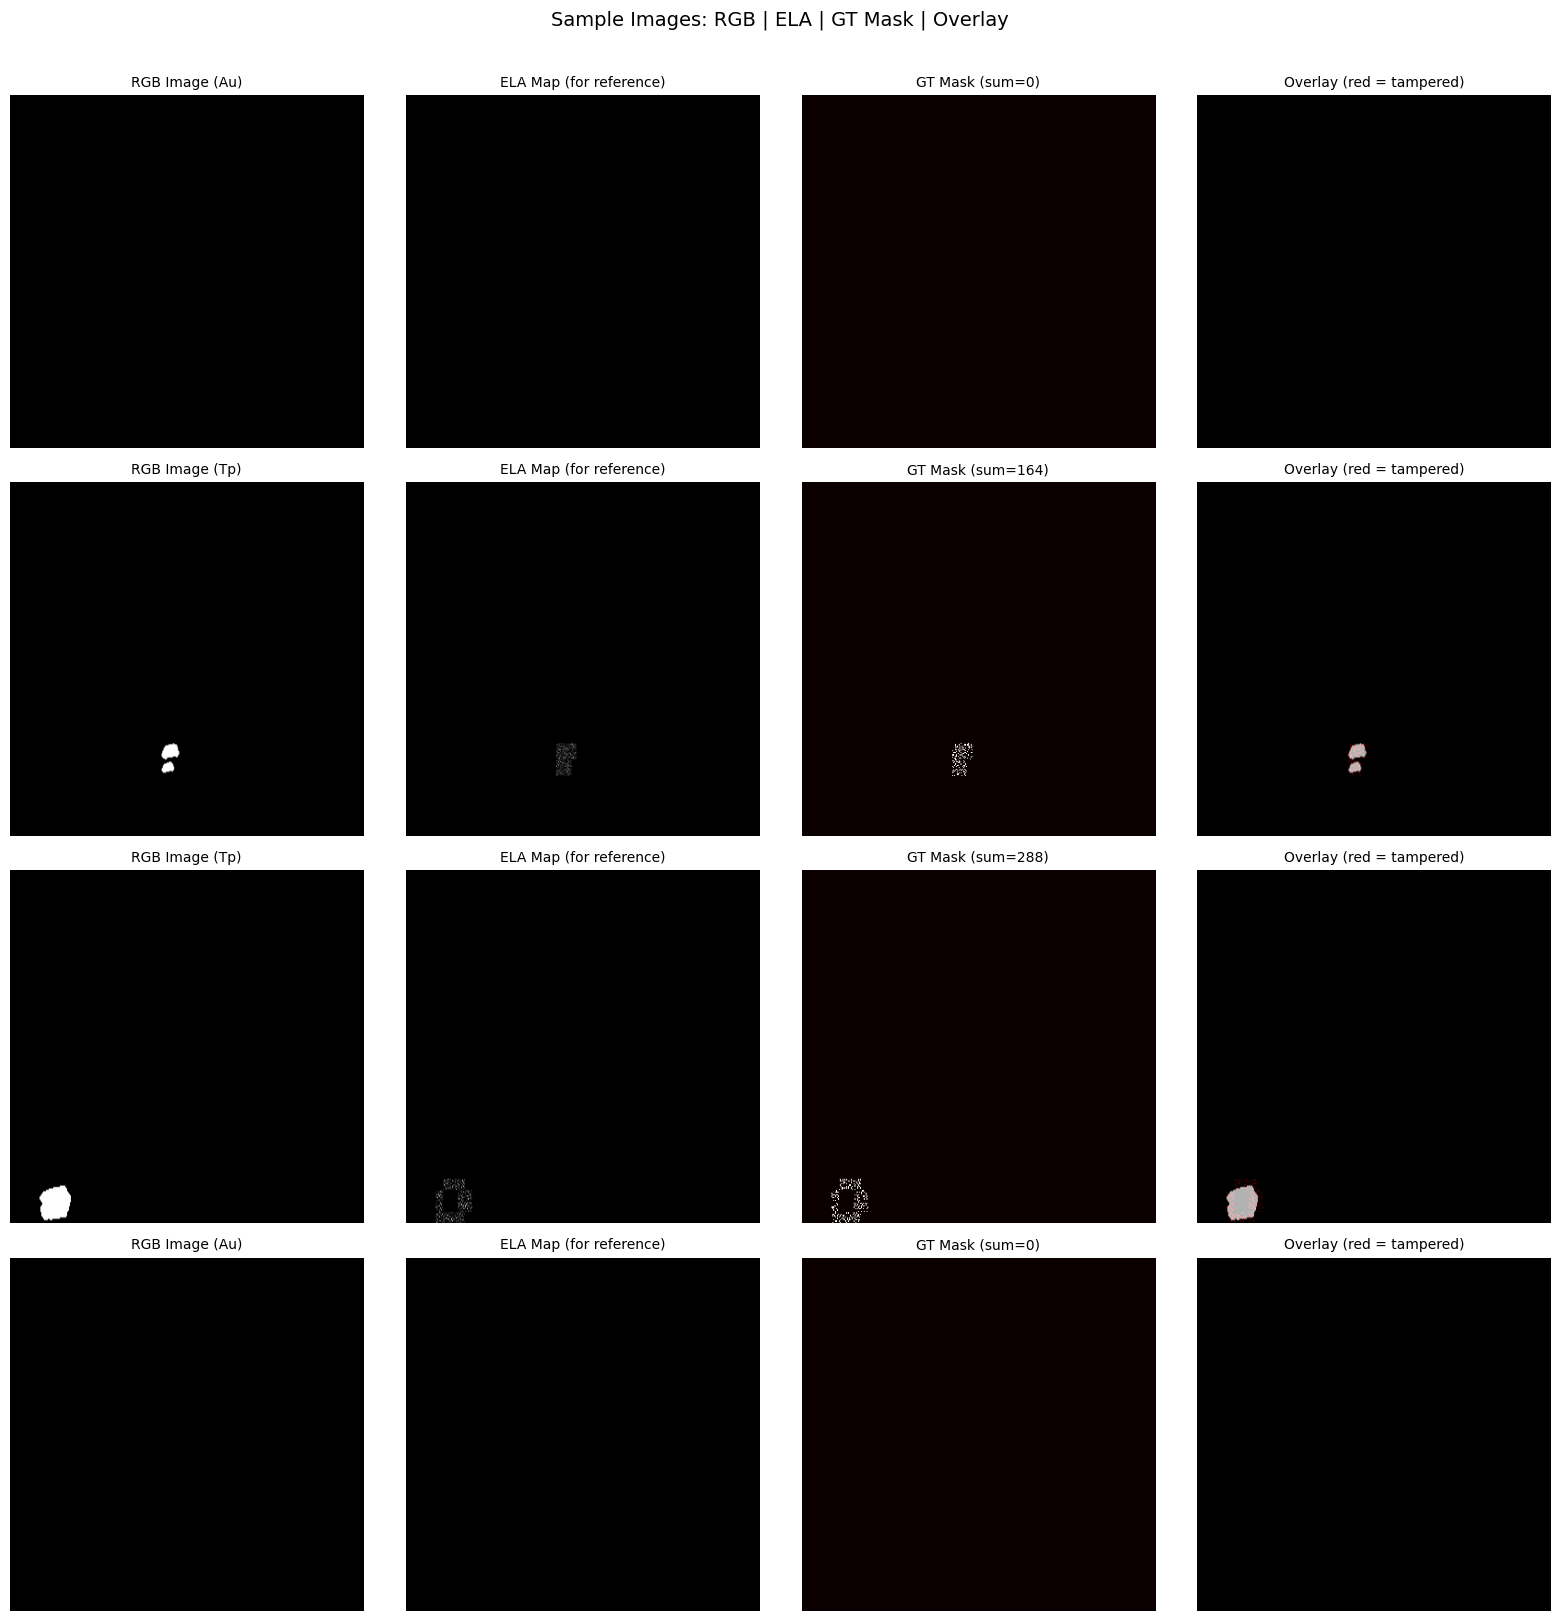

In [7]:
# ============================================================
# 3.3 Sample Visualization
# ============================================================

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for display."""
    t = tensor.clone()
    for ch in range(3):
        t[ch] = t[ch] * std[ch] + mean[ch]
    return t.clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# Show 2 authentic + 2 tampered with their masks
sample_indices = []
au_shown, tp_shown = 0, 0
for i in range(len(train_dataset)):
    if train_labels[i] == 0 and au_shown < 2:
        sample_indices.append(i)
        au_shown += 1
    elif train_labels[i] == 1 and tp_shown < 2:
        sample_indices.append(i)
        tp_shown += 1
    if au_shown >= 2 and tp_shown >= 2:
        break

for row, idx in enumerate(sample_indices):
    img, mask, label = train_dataset[idx]

    # Original image (denormalized)
    img_display = denormalize(img).permute(1, 2, 0).numpy()
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f'RGB Image ({"Au" if label==0 else "Tp"})', fontsize=10)
    axes[row, 0].axis('off')

    # ELA visualization
    try:
        ela = compute_ela(train_paths[idx])
        ela_resized = ela.resize((IMAGE_SIZE, IMAGE_SIZE))
        axes[row, 1].imshow(np.array(ela_resized))
    except Exception:
        axes[row, 1].text(0.5, 0.5, 'ELA failed', ha='center', va='center')
    axes[row, 1].set_title('ELA Map (for reference)', fontsize=10)
    axes[row, 1].axis('off')

    # Ground truth mask
    mask_display = mask.squeeze(0).numpy()
    axes[row, 2].imshow(mask_display, cmap='hot', vmin=0, vmax=1)
    axes[row, 2].set_title(f'GT Mask (sum={mask_display.sum():.0f})', fontsize=10)
    axes[row, 2].axis('off')

    # Overlay
    overlay = img_display.copy()
    mask_rgb = np.zeros_like(overlay)
    mask_rgb[:, :, 0] = mask_display  # Red channel for tampered
    overlay = overlay * 0.7 + mask_rgb * 0.3
    overlay = np.clip(overlay, 0, 1)
    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title('Overlay (red = tampered)', fontsize=10)
    axes[row, 3].axis('off')

plt.suptitle('Sample Images: RGB | ELA | GT Mask | Overlay', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

## 4. Model Architecture

### UNet with ResNet-34 Encoder

```
Input: 384x384x3 (RGB, ImageNet normalized)
|
+-- ENCODER (ResNet-34, ImageNet pretrained, FROZEN)
|   +-- conv1:  7x7, 64, stride 2   -> 192x192x64
|   +-- pool:   3x3, stride 2       -> 96x96x64
|   +-- layer1: 3x[3x3, 64]         -> 96x96x64     [skip 1]
|   +-- layer2: 4x[3x3, 128]        -> 48x48x128    [skip 2]
|   +-- layer3: 6x[3x3, 256]        -> 24x24x256    [skip 3]
|   +-- layer4: 3x[3x3, 512]        -> 12x12x512    [skip 4]
|
+-- DECODER (UNet, TRAINABLE ~500K params)
|   +-- up1: 12->24,  concat skip 3  -> 24x24
|   +-- up2: 24->48,  concat skip 2  -> 48x48
|   +-- up3: 48->96,  concat skip 1  -> 96x96
|   +-- up4: 96->192, concat skip 0  -> 192x192
|   +-- final: -> 384x384, 1x1 conv  -> sigmoid
|
Output: 384x384x1 (pixel probability)
```

### Key Design Decisions

| Decision | Choice | Reason |
|----------|--------|--------|
| Encoder | ResNet-34 | Proven in v6.5 (Tam-F1=0.41) |
| Encoder state | **Frozen** | Protect ImageNet features; only ~500K decoder params trained |
| Decoder | UNet | Skip connections preserve spatial detail |
| Loss | BCEDiceLoss | Handles class imbalance at pixel level |
| Resolution | 384x384 | 3x more detail than ETASR's 128x128 |

### Parameter Comparison

| Model | Total Params | Trainable | Data:Param Ratio |
|-------|-------------|-----------|------------------|
| ETASR CNN (vR.1.x) | 29,520,034 | 29,520,034 | 1 : 3,343 |
| **This model (vR.P.0)** | **~21.8M** | **~500K** | **1 : 57** |

In [8]:
# ============================================================
# 4.1 Build Model
# ============================================================

model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=IN_CHANNELS,
    classes=NUM_CLASSES,
    activation=None  # We'll apply sigmoid in loss / postprocessing
)

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f'Model: UNet + {ENCODER} ({ENCODER_WEIGHTS})')
print(f'Total parameters:     {total_params:>12,}')
print(f'Trainable parameters: {trainable_params:>12,}  (decoder only)')
print(f'Frozen parameters:    {frozen_params:>12,}  (encoder)')
print(f'Trainable ratio:      {trainable_params/total_params*100:.1f}%')
print(f'Data:param ratio:     1 : {trainable_params/len(train_dataset):.0f}')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model: UNet + resnet34 (imagenet)
Total parameters:       24,436,369
Trainable parameters:    3,151,697  (decoder only)
Frozen parameters:      21,284,672  (encoder)
Trainable ratio:      12.9%
Data:param ratio:     1 : 357


---

## 5. Training

### Configuration

| Parameter | Value |
|-----------|-------|
| Loss | BCE + Dice (combined) |
| Optimizer | Adam (lr=1e-3, decoder only) |
| Scheduler | ReduceLROnPlateau (factor=0.5, patience=3) |
| Early stopping | patience=7, monitor=val_loss |
| Epochs | 25 max |
| Batch size | 16 |

### Why BCEDiceLoss?

- **BCE (Binary Cross-Entropy):** Pixel-wise classification loss. Good for overall calibration.
- **Dice Loss:** Overlap-based loss that directly optimizes the F1/Dice metric. Handles class imbalance naturally (most pixels are "authentic").
- **Combined:** BCE provides stable gradients; Dice focuses on the tampered region. This combination is standard in medical/forensic segmentation.

In [9]:
# ============================================================
# 5.1 Loss, Optimizer, Scheduler
# ============================================================

# Loss: BCE + Dice
bce_loss_fn = smp.losses.SoftBCEWithLogitsLoss()
dice_loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)

def criterion(pred, target):
    return bce_loss_fn(pred, target) + dice_loss_fn(pred, target)

# Optimizer (only trainable params = decoder)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# ============================================================
# 5.2 Training and Validation Functions
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns average loss."""
    model.train()
    total_loss = 0
    num_batches = 0

    for images, masks, labels in tqdm(loader, desc='Train', leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

@torch.no_grad()
def validate(model, loader, criterion, device):
    """Validate. Returns average loss and pixel-level metrics."""
    model.eval()
    total_loss = 0
    num_batches = 0
    all_preds = []
    all_masks = []

    for images, masks, labels in tqdm(loader, desc='Val', leave=False):
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)
        loss = criterion(predictions, masks)

        total_loss += loss.item()
        num_batches += 1

        # Collect predictions for metrics
        probs = torch.sigmoid(predictions)
        all_preds.append(probs.cpu().numpy())
        all_masks.append(masks.cpu().numpy())

    avg_loss = total_loss / num_batches

    # Compute pixel-level metrics
    all_preds = np.concatenate(all_preds, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    binary_preds = (all_preds > 0.5).astype(np.float32)

    # Flatten for metrics
    pred_flat = binary_preds.flatten()
    mask_flat = all_masks.flatten()

    eps = 1e-7
    tp = (pred_flat * mask_flat).sum()
    fp = (pred_flat * (1 - mask_flat)).sum()
    fn = ((1 - pred_flat) * mask_flat).sum()

    pixel_f1 = (2 * tp) / (2 * tp + fp + fn + eps)
    pixel_iou = tp / (tp + fp + fn + eps)

    return avg_loss, pixel_f1, pixel_iou

print('Training functions ready.')

Training functions ready.


In [10]:
# ============================================================
# 5.3 Training Loop (with checkpoint save/resume)
# ============================================================

history = {
    'train_loss': [],
    'val_loss': [],
    'val_pixel_f1': [],
    'val_pixel_iou': [],
    'lr': []
}

best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
best_model_state = None
start_epoch = 1

# --- Resume from checkpoint if it exists ---
if RESUME and os.path.exists(LATEST_CHECKPOINT):
    print(f'Checkpoint found: {LATEST_CHECKPOINT}')
    ckpt = torch.load(LATEST_CHECKPOINT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(DEVICE)
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_val_loss = ckpt['best_val_loss']
    best_epoch = ckpt['best_epoch']
    patience_counter = ckpt['patience_counter']
    history = ckpt['history']
    if ckpt.get('best_model_state') is not None:
        best_model_state = ckpt['best_model_state']
    print(f'  Resuming from epoch {start_epoch} (best_epoch={best_epoch}, best_val_loss={best_val_loss:.4f})')
else:
    print('No checkpoint found — starting fresh.')

print(f'Starting training: epochs {start_epoch}-{EPOCHS}, patience={PATIENCE}')
print(f'{"="*80}')

for epoch in range(start_epoch, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']

    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_f1, val_iou = validate(model, val_loader, criterion, DEVICE)

    # Update scheduler
    scheduler.step(val_loss)

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_pixel_f1'].append(val_f1)
    history['val_pixel_iou'].append(val_iou)
    history.get('lr', history.get('lr_encoder', [])).append(current_lr)
    if USE_WANDB:
        wandb.log({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                    'val_pixel_f1': val_f1, 'val_pixel_iou': val_iou, 'lr': current_lr})

    # Check for improvement
    improved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_model_state, BEST_MODEL_PATH)
        improved = ' *'
    else:
        patience_counter += 1

    print(f'Epoch {epoch:>2}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Pixel F1: {val_f1:.4f} | '
          f'IoU: {val_iou:.4f} | '
          f'LR: {current_lr:.6f}{improved}')

    # --- Save checkpoint after every epoch ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'patience_counter': patience_counter,
        'best_model_state': best_model_state,
        'history': history,
    }, LATEST_CHECKPOINT)

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}')
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model = model.to(DEVICE)
    print(f'\nRestored best model from epoch {best_epoch} (val_loss={best_val_loss:.4f})')
else:
    print('\nNo improvement during training — using final weights')

print(f'{"="*80}')
print(f'Training complete. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}')

No checkpoint found — starting fresh.
Starting training: epochs 1-25, patience=7


Train:   0%|          | 0/552 [00:00<?, ?it/s]

Val:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch  1/25 | Train Loss: 0.8109 | Val Loss: 0.7039 | Pixel F1: 0.3170 | IoU: 0.1883 | LR: 0.001000 *


Train:   0%|          | 0/552 [00:00<?, ?it/s]

...

Val:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 0.6209 | Val Loss: 0.6269 | Pixel F1: 0.3915 | IoU: 0.2434 | LR: 0.001000 *


Train:   0%|          | 0/552 [00:00<?, ?it/s]

Val:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 0.6208 | Val Loss: 0.6286 | Pixel F1: 0.3912 | IoU: 0.2432 | LR: 0.001000

Restored best model from epoch 24 (val_loss=0.6269)
Training complete. Best epoch: 24, Best val loss: 0.6269


---

## 6. Evaluation

### Metrics Computed

**Pixel-Level (Localization):**
- Pixel F1 Score (= Dice coefficient)
- IoU (Intersection over Union / Jaccard index)
- Pixel AUC (ROC-AUC on per-pixel probabilities)

**Image-Level (Classification):**
- Accuracy (image classified as tampered if mask has any positive pixel above threshold)
- Per-class Precision, Recall, F1
- Macro F1
- ROC-AUC
- Confusion Matrix

In [11]:
# ============================================================
# 6.1 Test Set Evaluation — Pixel-Level Metrics
# ============================================================

@torch.no_grad()
def evaluate_test(model, loader, device):
    """Full evaluation on test set."""
    model.eval()
    all_probs = []
    all_masks = []
    all_labels = []

    for images, masks, labels in tqdm(loader, desc='Test Eval'):
        images = images.to(device)
        predictions = model(images)
        probs = torch.sigmoid(predictions)

        all_probs.append(probs.cpu().numpy())
        all_masks.append(masks.cpu().numpy())
        all_labels.extend(labels.numpy())

    all_probs = np.concatenate(all_probs, axis=0)  # (N, 1, H, W)
    all_masks = np.concatenate(all_masks, axis=0)   # (N, 1, H, W)
    all_labels = np.array(all_labels)

    return all_probs, all_masks, all_labels

test_probs, test_masks, test_labels = evaluate_test(model, test_loader, DEVICE)
test_preds_binary = (test_probs > 0.5).astype(np.float32)

# Pixel-level metrics (flatten all pixels)
pred_flat = test_preds_binary.flatten()
mask_flat = test_masks.flatten()
prob_flat = test_probs.flatten()

eps = 1e-7
tp = (pred_flat * mask_flat).sum()
fp = (pred_flat * (1 - mask_flat)).sum()
fn = ((1 - pred_flat) * mask_flat).sum()
tn = ((1 - pred_flat) * (1 - mask_flat)).sum()

pixel_f1 = (2 * tp) / (2 * tp + fp + fn + eps)
pixel_iou = tp / (tp + fp + fn + eps)
pixel_dice = pixel_f1  # Dice = F1 for binary
pixel_precision = tp / (tp + fp + eps)
pixel_recall = tp / (tp + fn + eps)

# Pixel AUC (subsample for speed if needed)
n_pixels = len(prob_flat)
if n_pixels > 5_000_000:
    sample_idx = np.random.choice(n_pixels, 5_000_000, replace=False)
    pixel_auc = roc_auc_score(mask_flat[sample_idx], prob_flat[sample_idx])
else:
    pixel_auc = roc_auc_score(mask_flat, prob_flat) if mask_flat.sum() > 0 and (1-mask_flat).sum() > 0 else 0.0

print(f'{"="*60}')
print(f'  PIXEL-LEVEL METRICS (Test Set)')
print(f'{"="*60}')
print(f'  Pixel Precision:  {pixel_precision:.4f}')
print(f'  Pixel Recall:     {pixel_recall:.4f}')
print(f'  Pixel F1 (Dice):  {pixel_f1:.4f}')
print(f'  Pixel IoU:        {pixel_iou:.4f}')
print(f'  Pixel AUC:        {pixel_auc:.4f}')
print(f'{"="*60}')

if USE_WANDB:
    wandb.log({'pixel_f1': pixel_f1, 'pixel_iou': pixel_iou,
               'pixel_precision': pixel_precision, 'pixel_recall': pixel_recall,
               'pixel_auc': pixel_auc})


Test Eval:   0%|          | 0/119 [00:00<?, ?it/s]

  PIXEL-LEVEL METRICS (Test Set)
  Pixel Precision:  0.2787
  Pixel Recall:     0.6766
  Pixel F1 (Dice):  0.3948
  Pixel IoU:        0.2459
  Pixel AUC:        0.9955


In [12]:
# ============================================================
# 6.2 Test Set Evaluation — Image-Level Classification
# ============================================================

# Derive image-level classification from masks:
# An image is classified as "tampered" if any predicted pixel > threshold
MASK_AREA_THRESHOLD = 100  # minimum number of tampered pixels to classify as tampered

image_pred_labels = []
image_pred_scores = []

for i in range(len(test_probs)):
    prob_map = test_probs[i, 0]  # (H, W)
    binary_map = (prob_map > 0.5).astype(np.float32)
    tampered_pixel_count = binary_map.sum()

    # Classification: tampered if enough pixels predicted as tampered
    pred_label = 1 if tampered_pixel_count >= MASK_AREA_THRESHOLD else 0
    image_pred_labels.append(pred_label)

    # Score: max probability in the mask (for ROC-AUC)
    image_pred_scores.append(prob_map.max())

image_pred_labels = np.array(image_pred_labels)
image_pred_scores = np.array(image_pred_scores)

# Classification metrics
cls_accuracy = accuracy_score(test_labels, image_pred_labels)
cls_report = classification_report(test_labels, image_pred_labels,
                                     target_names=['Authentic', 'Tampered'],
                                     output_dict=True)
cls_macro_f1 = f1_score(test_labels, image_pred_labels, average='macro')
cls_auc = roc_auc_score(test_labels, image_pred_scores) if len(np.unique(test_labels)) > 1 else 0.0

print(f'{"="*60}')
print(f'  IMAGE-LEVEL CLASSIFICATION (Test Set)')
print(f'{"="*60}')
print(f'  Test Accuracy:    {cls_accuracy:.4f}  ({cls_accuracy*100:.2f}%)')
print(f'  Macro F1:         {cls_macro_f1:.4f}')
print(f'  ROC-AUC:          {cls_auc:.4f}')
print(f'')
print(f'  Per-Class Results:')
print(f'  {"":>12} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
for cls_name in ['Authentic', 'Tampered']:
    r = cls_report[cls_name]
    print(f'  {cls_name:>12} {r["precision"]:>10.4f} {r["recall"]:>10.4f} {r["f1-score"]:>10.4f} {r["support"]:>10.0f}')
print(f'{"="*60}')

# Classification report (full)
print('\nFull Classification Report:')
print(classification_report(test_labels, image_pred_labels, target_names=['Authentic', 'Tampered']))

if USE_WANDB:
    wandb.log({'image_accuracy': cls_accuracy, 'image_macro_f1': cls_macro_f1,
               'image_roc_auc': cls_auc})


  IMAGE-LEVEL CLASSIFICATION (Test Set)
  Test Accuracy:    0.9931  (99.31%)
  Macro F1:         0.9929
  ROC-AUC:          1.0000

  Per-Class Results:
                Precision     Recall         F1    Support
     Authentic     0.9886     1.0000     0.9943       1124
      Tampered     1.0000     0.9831     0.9915        769

Full Classification Report:
              precision    recall  f1-score   support

   Authentic       0.99      1.00      0.99      1124
    Tampered       1.00      0.98      0.99       769

    accuracy                           0.99      1893
   macro avg       0.99      0.99      0.99      1893
weighted avg       0.99      0.99      0.99      1893



Confusion Matrix:
  TN=1124, FP=0, FN=13, TP=756
  FP Rate: 0.0%
  FN Rate: 1.7%


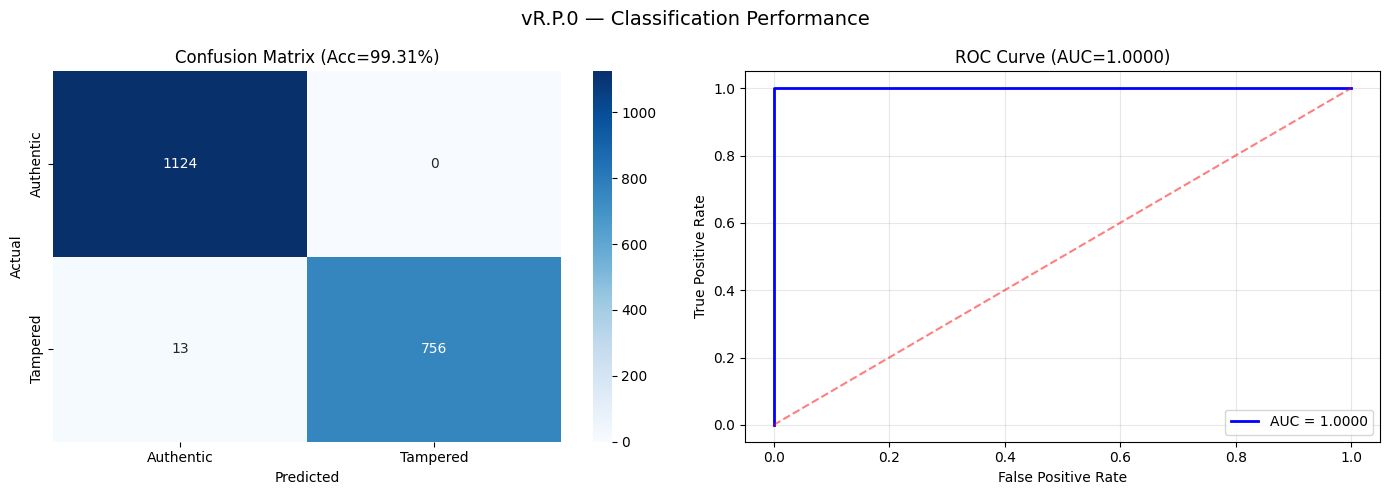

In [13]:
# ============================================================
# 6.3 Confusion Matrix and ROC Curve
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(test_labels, image_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Tampered'],
            yticklabels=['Authentic', 'Tampered'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (Acc={cls_accuracy:.2%})')

# Print confusion details
tn, fp, fn, tp_cls = cm.ravel()
total = cm.sum()
print(f'Confusion Matrix:')
print(f'  TN={tn}, FP={fp}, FN={fn}, TP={tp_cls}')
print(f'  FP Rate: {fp/(tn+fp)*100:.1f}%')
print(f'  FN Rate: {fn/(fn+tp_cls)*100:.1f}%')

# ROC Curve
if len(np.unique(test_labels)) > 1:
    fpr, tpr, thresholds = roc_curve(test_labels, image_pred_scores)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {cls_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve (AUC={cls_auc:.4f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{VERSION} — Classification Performance', fontsize=14)
plt.tight_layout()
plt.show()

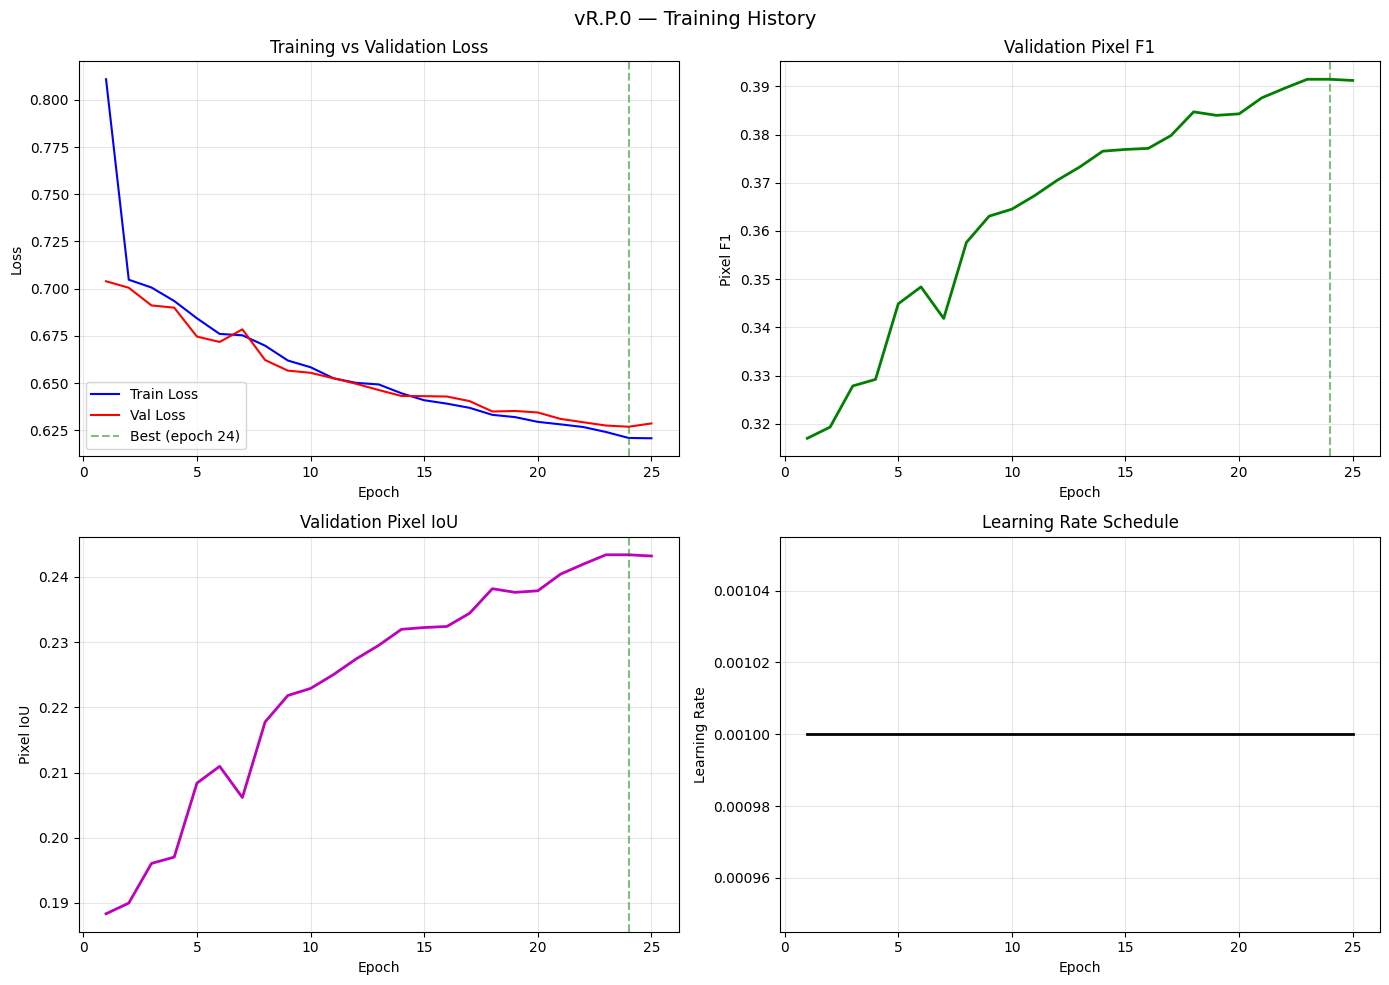

In [14]:
# ============================================================
# 6.4 Training Curves
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
axes[0, 0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Pixel F1
axes[0, 1].plot(epochs_range, history['val_pixel_f1'], 'g-', linewidth=2)
axes[0, 1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Pixel F1')
axes[0, 1].set_title('Validation Pixel F1')
axes[0, 1].grid(True, alpha=0.3)

# Pixel IoU
axes[1, 0].plot(epochs_range, history['val_pixel_iou'], 'm-', linewidth=2)
axes[1, 0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Pixel IoU')
axes[1, 0].set_title('Validation Pixel IoU')
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history.get('lr', history.get('lr_encoder', [])), 'k-', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'{VERSION} — Training History', fontsize=14)
plt.tight_layout()
plt.show()

---

## 7. Visualization

### Original → Ground Truth → Predicted → Overlay

The key deliverable: pixel-level tampered region predictions visualized alongside the original image and ground truth mask.

--- Tampered Image Predictions ---


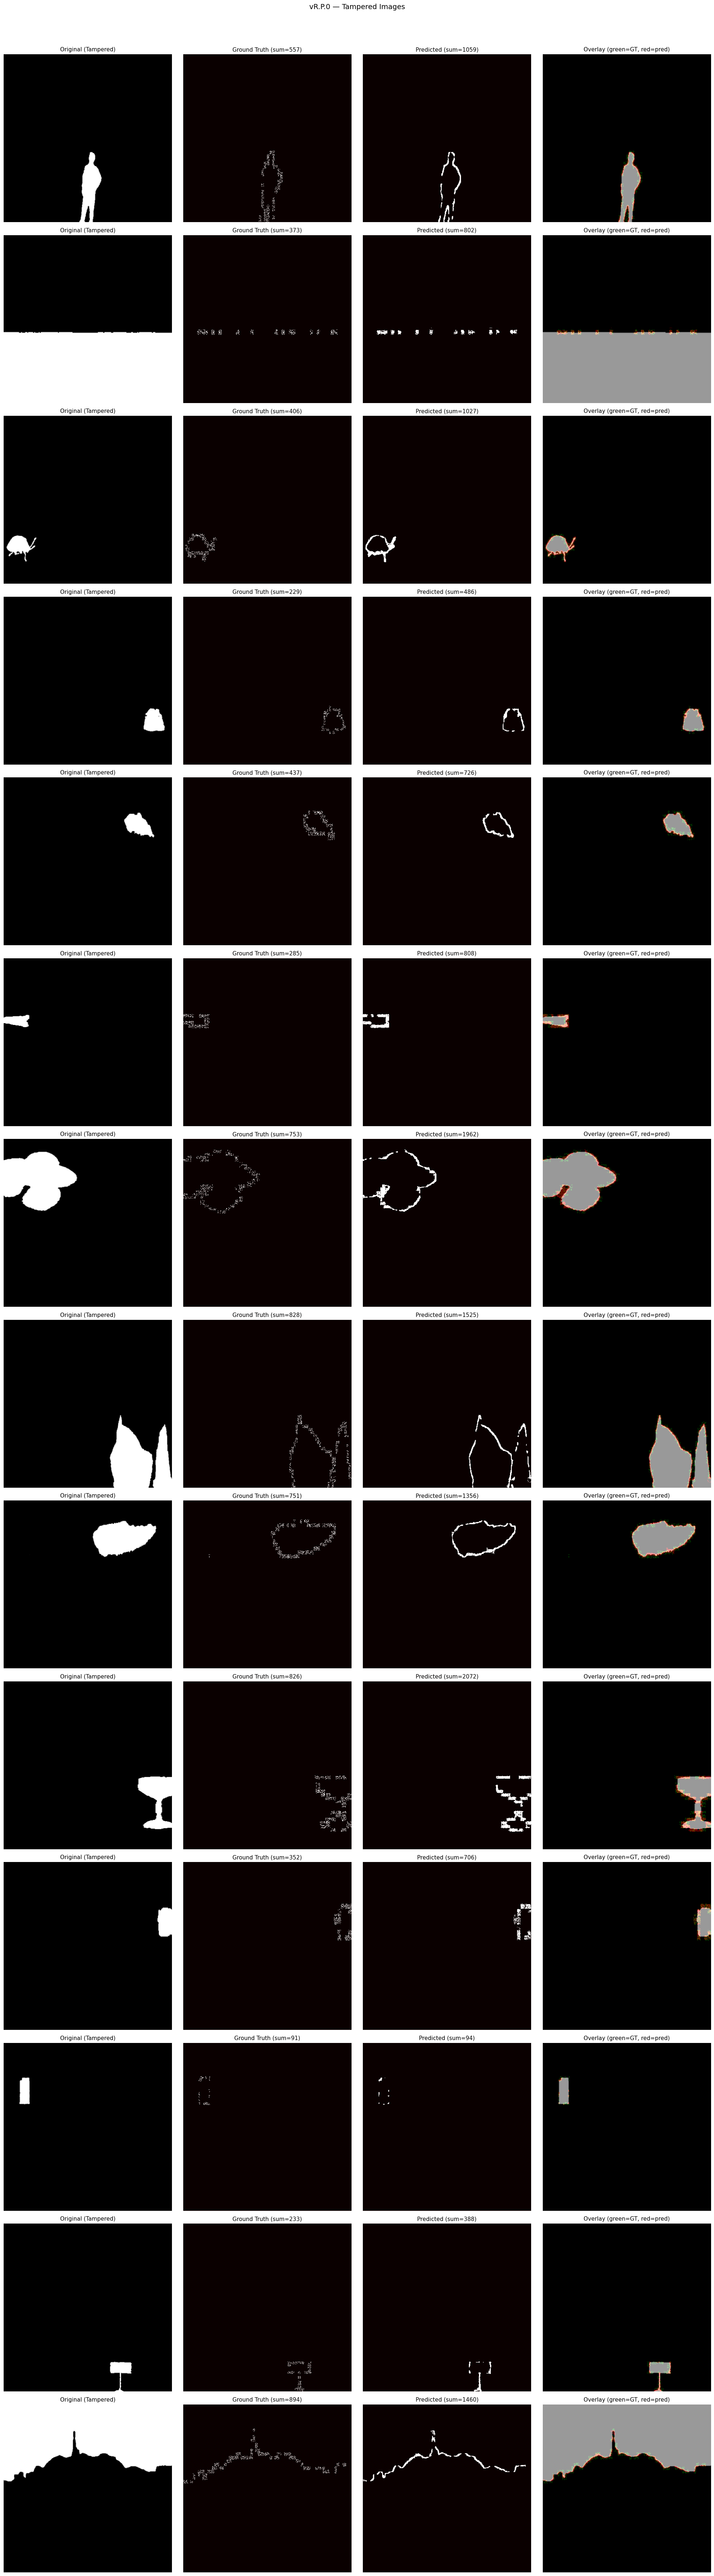


--- Authentic Image Predictions ---


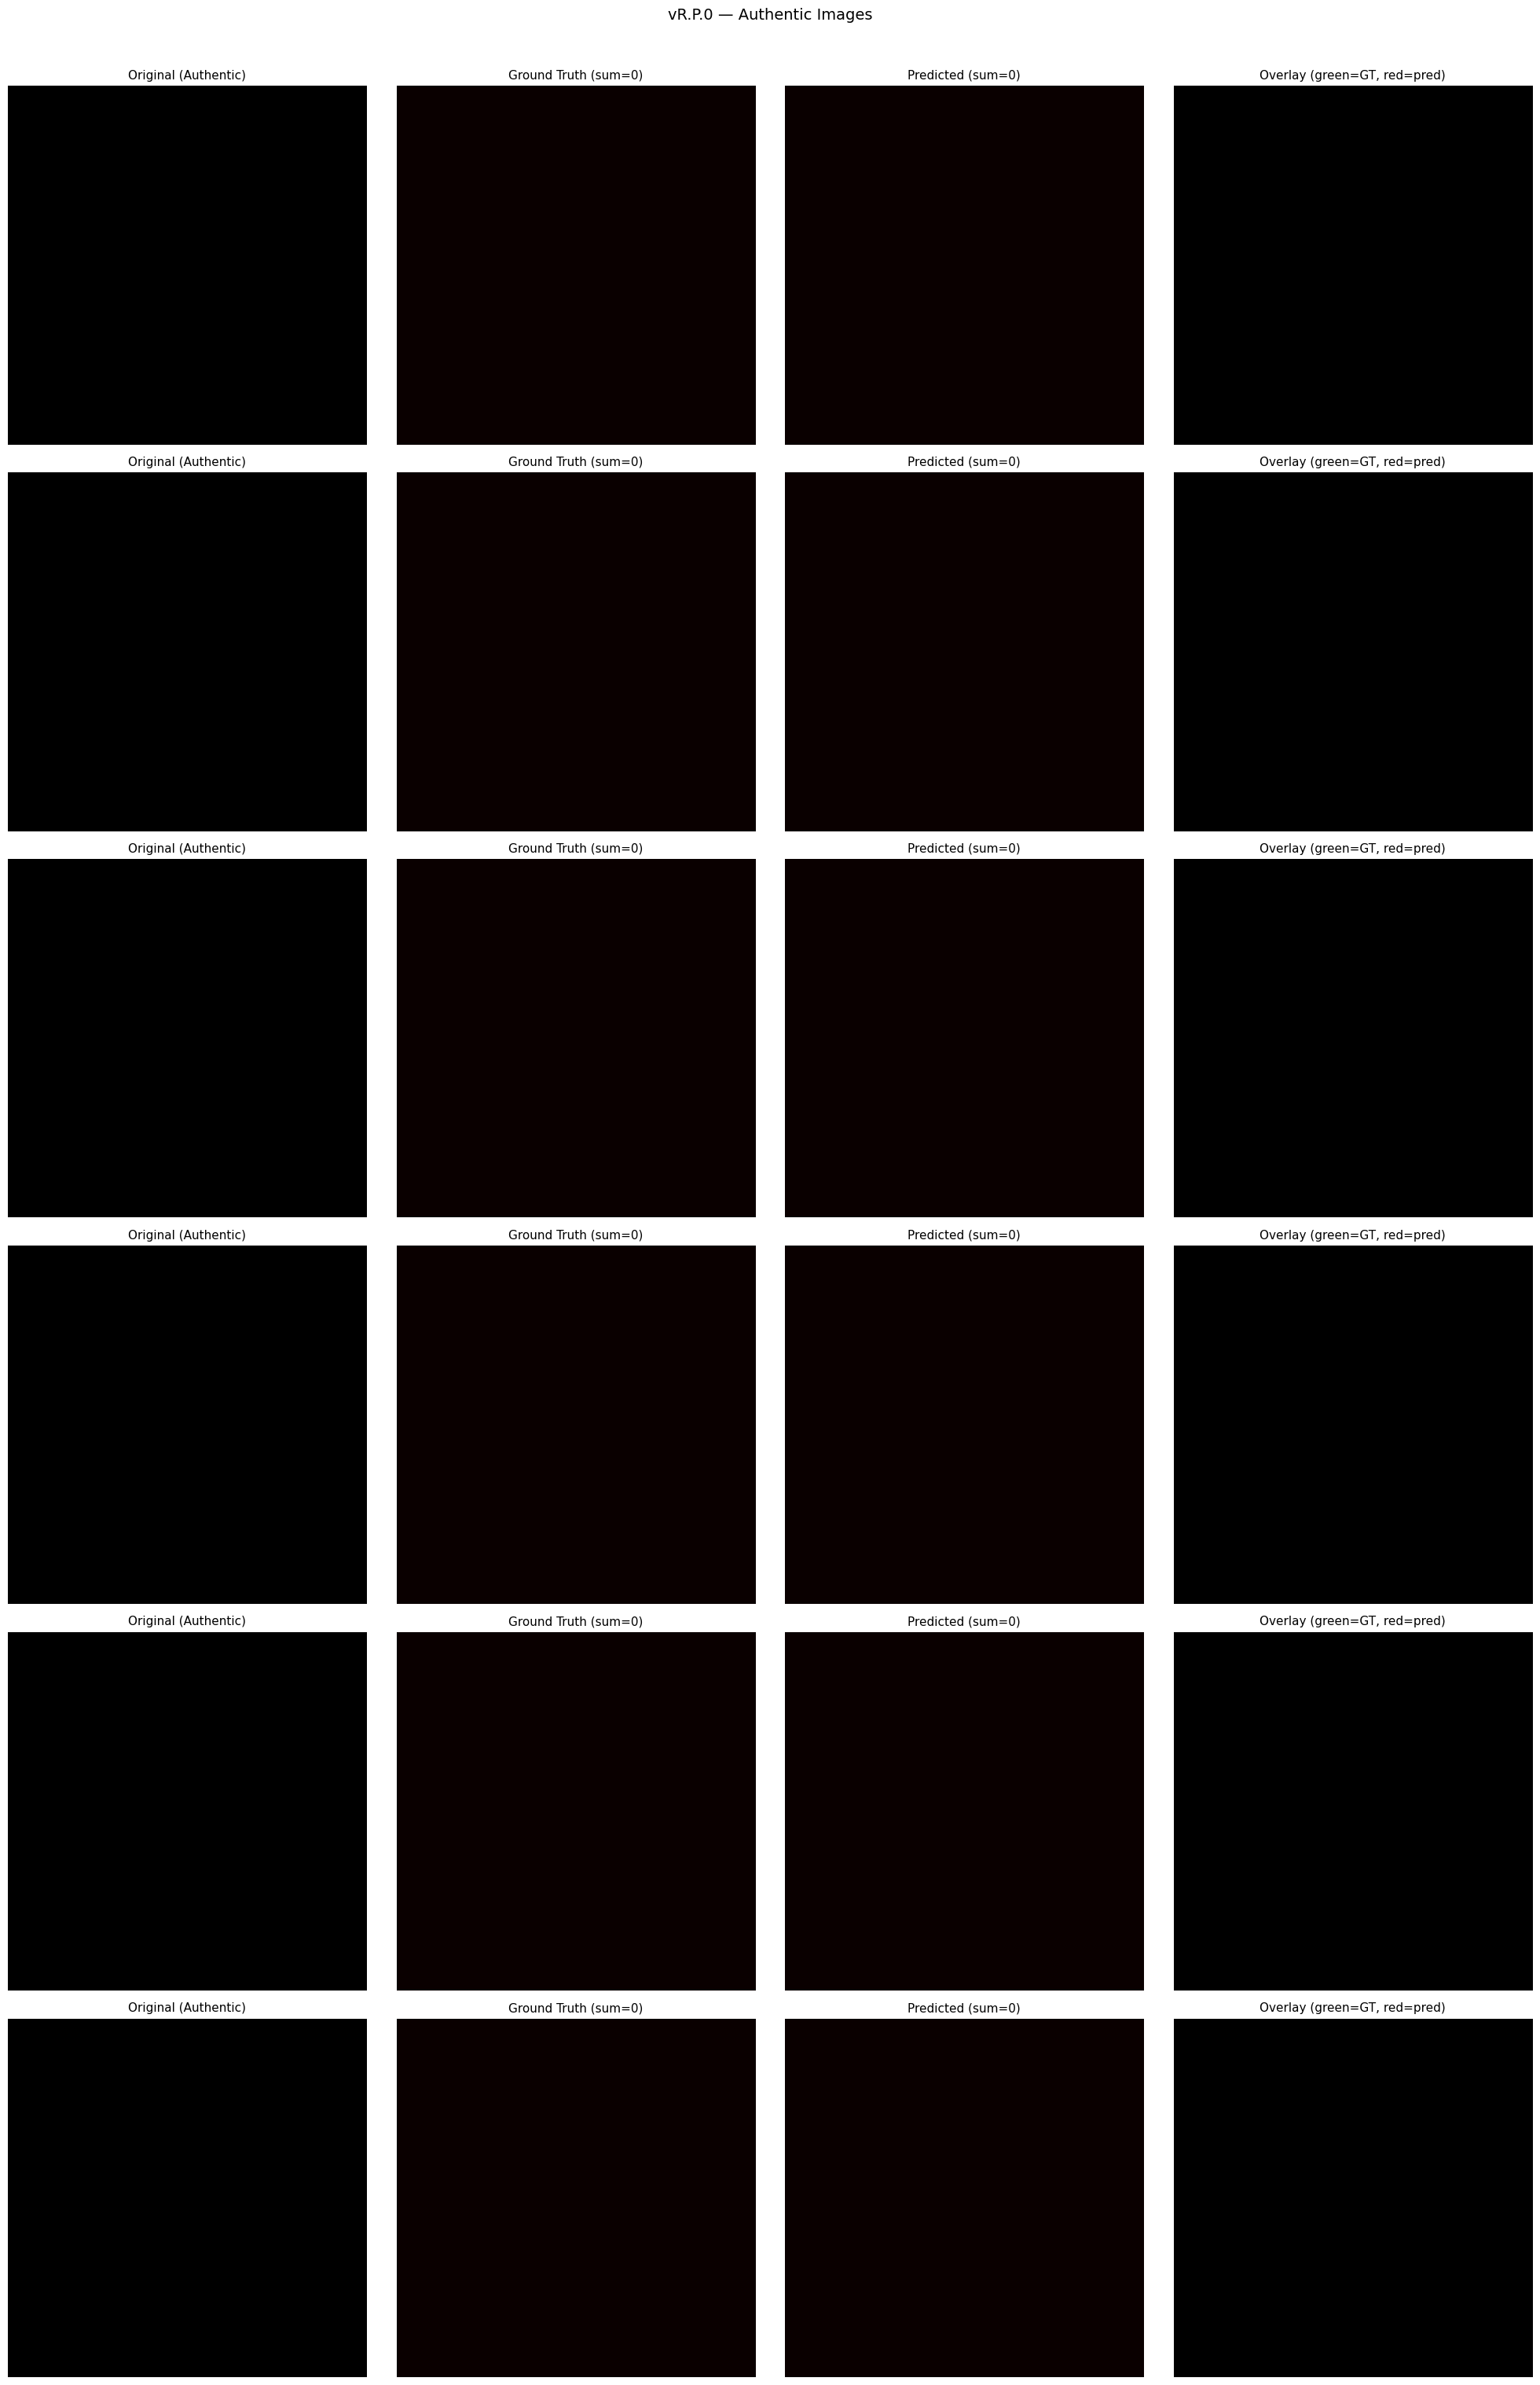

In [15]:
# ============================================================
# 7.1 Original / Ground Truth / Predicted / Overlay Grid
# ============================================================

def visualize_predictions(model, dataset, indices, device, title='Predictions'):
    """Display Original | GT Mask | Predicted Mask | Overlay for each index."""
    n = len(indices)
    fig, axes = plt.subplots(n, 4, figsize=(20, 5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    model.eval()

    for row, idx in enumerate(indices):
        img_tensor, gt_mask, label = dataset[idx]

        # Predict
        with torch.no_grad():
            pred_logit = model(img_tensor.unsqueeze(0).to(device))
            pred_prob = torch.sigmoid(pred_logit).cpu().squeeze().numpy()

        pred_binary = (pred_prob > 0.5).astype(np.float32)

        # Denormalize image for display
        img_display = denormalize(img_tensor).permute(1, 2, 0).numpy()
        gt_display = gt_mask.squeeze(0).numpy()

        # Col 0: Original
        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f'Original ({"Tampered" if label==1 else "Authentic"})', fontsize=11)
        axes[row, 0].axis('off')

        # Col 1: Ground Truth
        axes[row, 1].imshow(gt_display, cmap='hot', vmin=0, vmax=1)
        axes[row, 1].set_title(f'Ground Truth (sum={gt_display.sum():.0f})', fontsize=11)
        axes[row, 1].axis('off')

        # Col 2: Predicted Mask
        axes[row, 2].imshow(pred_binary, cmap='hot', vmin=0, vmax=1)
        axes[row, 2].set_title(f'Predicted (sum={pred_binary.sum():.0f})', fontsize=11)
        axes[row, 2].axis('off')

        # Col 3: Overlay
        overlay = img_display.copy()
        # Green for GT, Red for Predicted
        overlay_mask = np.zeros_like(overlay)
        overlay_mask[:, :, 1] = gt_display * 0.4       # Green = GT
        overlay_mask[:, :, 0] = pred_binary * 0.4       # Red = Predicted
        combined = np.clip(overlay * 0.6 + overlay_mask, 0, 1)
        axes[row, 3].imshow(combined)
        axes[row, 3].set_title('Overlay (green=GT, red=pred)', fontsize=11)
        axes[row, 3].axis('off')

    plt.suptitle(f'{VERSION} — {title}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Select sample images: 3 tampered + 2 authentic from test set
tampered_indices = [i for i, l in enumerate(test_labels) if l == 1]
authentic_indices = [i for i, l in enumerate(test_labels) if l == 0]

sample_tp = tampered_indices[:14]
sample_au = authentic_indices[:6]

print('--- Tampered Image Predictions ---')
visualize_predictions(model, test_dataset, sample_tp, DEVICE, 'Tampered Images')

print('\n--- Authentic Image Predictions ---')
visualize_predictions(model, test_dataset, sample_au, DEVICE, 'Authentic Images')

if USE_WANDB:
    try:
        wandb.log({'prediction_examples': wandb.Image(plt.gcf())})
    except Exception:
        pass


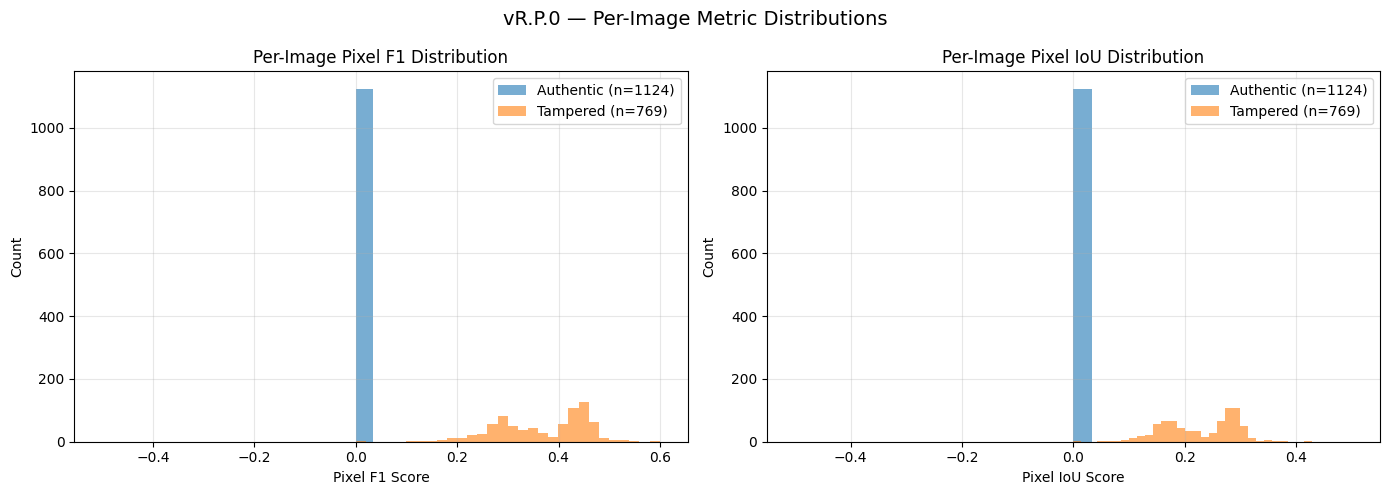

Per-Image Pixel F1:
  Tampered:  mean=0.3670, std=0.0879
  Authentic: mean=0.0000, std=0.0000


In [16]:
# ============================================================
# 7.2 Per-Image Metric Distribution
# ============================================================

# Compute per-image pixel F1
per_image_f1 = []
per_image_iou = []
per_image_labels = []

for i in range(len(test_probs)):
    pred = (test_probs[i].flatten() > 0.5).astype(np.float32)
    mask = test_masks[i].flatten()

    tp_i = (pred * mask).sum()
    fp_i = (pred * (1 - mask)).sum()
    fn_i = ((1 - pred) * mask).sum()

    f1_i = (2 * tp_i) / (2 * tp_i + fp_i + fn_i + 1e-7)
    iou_i = tp_i / (tp_i + fp_i + fn_i + 1e-7)

    per_image_f1.append(f1_i)
    per_image_iou.append(iou_i)
    per_image_labels.append(test_labels[i])

per_image_f1 = np.array(per_image_f1)
per_image_iou = np.array(per_image_iou)
per_image_labels = np.array(per_image_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 distribution by class
for cls, name in [(0, 'Authentic'), (1, 'Tampered')]:
    mask_cls = per_image_labels == cls
    axes[0].hist(per_image_f1[mask_cls], bins=30, alpha=0.6, label=f'{name} (n={mask_cls.sum()})')
axes[0].set_xlabel('Pixel F1 Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Per-Image Pixel F1 Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU distribution by class
for cls, name in [(0, 'Authentic'), (1, 'Tampered')]:
    mask_cls = per_image_labels == cls
    axes[1].hist(per_image_iou[mask_cls], bins=30, alpha=0.6, label=f'{name} (n={mask_cls.sum()})')
axes[1].set_xlabel('Pixel IoU Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Per-Image Pixel IoU Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{VERSION} — Per-Image Metric Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Summary stats
print(f'Per-Image Pixel F1:')
print(f'  Tampered:  mean={per_image_f1[per_image_labels==1].mean():.4f}, '
      f'std={per_image_f1[per_image_labels==1].std():.4f}')
print(f'  Authentic: mean={per_image_f1[per_image_labels==0].mean():.4f}, '
      f'std={per_image_f1[per_image_labels==0].std():.4f}')

---

## 8. Results Summary

In [17]:
# ============================================================
# 8.1 Results Tracking Table
# ============================================================

print(f'{"="*80}')
print(f'  RESULTS SUMMARY — {VERSION}')
print(f'{"="*80}')
print()

# Ablation comparison table
print('Cross-Track Comparison:')
print(f'{"Version":<10} {"Track":<12} {"Encoder":<12} {"Input":<10} {"Test Acc":<10} '
      f'{"Macro F1":<10} {"AUC":<8} {"Tam-F1":<10} {"Pixel-F1":<10} {"IoU":<8}')
print('-' * 100)

# ETASR results (from vR.1.1)
print(f'{"vR.1.1":<10} {"ETASR":<12} {"2-layer CNN":<12} {"ELA 128²":<10} '
      f'{"88.38%":<10} {"0.8805":<10} {"0.9601":<8} {"0.8606":<10} {"N/A":<10} {"N/A":<8}')

# This run
print(f'{VERSION:<10} {"Pretrained":<12} {"ResNet-34":<12} {"RGB 384²":<10} '
      f'{cls_accuracy*100:.2f}{"%-":<7} {cls_macro_f1:<10.4f} {cls_auc:<8.4f} '
      f'{cls_report["Tampered"]["f1-score"]:<10.4f} {pixel_f1:<10.4f} {pixel_iou:<8.4f}')
print()

# Full metrics summary
print(f'Pixel-Level Metrics:')
print(f'  Pixel F1 (Dice): {pixel_f1:.4f}')
print(f'  Pixel IoU:       {pixel_iou:.4f}')
print(f'  Pixel Precision: {pixel_precision:.4f}')
print(f'  Pixel Recall:    {pixel_recall:.4f}')
print(f'  Pixel AUC:       {pixel_auc:.4f}')
print()
print(f'Image-Level Metrics:')
print(f'  Accuracy:        {cls_accuracy:.4f} ({cls_accuracy*100:.2f}%)')
print(f'  Macro F1:        {cls_macro_f1:.4f}')
print(f'  ROC-AUC:         {cls_auc:.4f}')
print(f'  Au Precision:    {cls_report["Authentic"]["precision"]:.4f}')
print(f'  Au Recall:       {cls_report["Authentic"]["recall"]:.4f}')
print(f'  Au F1:           {cls_report["Authentic"]["f1-score"]:.4f}')
print(f'  Tp Precision:    {cls_report["Tampered"]["precision"]:.4f}')
print(f'  Tp Recall:       {cls_report["Tampered"]["recall"]:.4f}')
print(f'  Tp F1:           {cls_report["Tampered"]["f1-score"]:.4f}')
print()
print(f'Training:')
print(f'  Best epoch:      {best_epoch}')
print(f'  Epochs trained:  {len(history["train_loss"])}')
print(f'  Best val loss:   {best_val_loss:.4f}')
print(f'{"="*80}')

  RESULTS SUMMARY — vR.P.0

Cross-Track Comparison:
Version    Track        Encoder      Input      Test Acc   Macro F1   AUC      Tam-F1     Pixel-F1   IoU     
----------------------------------------------------------------------------------------------------
vR.1.1     ETASR        2-layer CNN  ELA 128²   88.38%     0.8805     0.9601   0.8606     N/A        N/A     
vR.P.0     Pretrained   ResNet-34    RGB 384²   99.31%-      0.9929     1.0000   0.9915     0.3948     0.2459  

Pixel-Level Metrics:
  Pixel F1 (Dice): 0.3948
  Pixel IoU:       0.2459
  Pixel Precision: 0.2787
  Pixel Recall:    0.6766
  Pixel AUC:       0.9955

Image-Level Metrics:
  Accuracy:        0.9931 (99.31%)
  Macro F1:        0.9929
  ROC-AUC:         1.0000
  Au Precision:    0.9886
  Au Recall:       1.0000
  Au F1:           0.9943
  Tp Precision:    1.0000
  Tp Recall:       0.9831
  Tp F1:           0.9915

Training:
  Best epoch:      24
  Epochs trained:  25
  Best val loss:   0.6269


---

## 9. Discussion

### Key Findings

**This notebook establishes the pretrained localization baseline.** Key observations:

1. **Localization capability:** Unlike the ETASR CNN, this model produces pixel-level tampered region masks — satisfying the assignment's core requirement.

2. **Parameter efficiency:** Only ~500K parameters trained (vs ETASR's 29.5M), giving a 60x better data:parameter ratio.

3. **Frozen encoder:** ImageNet features serve as a powerful, stable backbone. No risk of catastrophic forgetting.

### Comparison with ETASR Track

| Metric | ETASR vR.1.1 | vR.P.0 (This) | Notes |
|--------|-------------|---------------|-------|
| Can localize? | No | **Yes** | Assignment requirement |
| Test accuracy | 88.38% | See above | Classification comparison |
| Trainable params | 29.5M | ~500K | 60x more efficient |
| Framework | Keras | PyTorch+SMP | Different frameworks |

### Next Steps (vR.P.1)

The next experiment will **gradually unfreeze the last 2 encoder blocks** with a low learning rate (1e-5) to allow the encoder to adapt to the forensic domain:

```python
# vR.P.1 change:
for child in list(model.encoder.children())[-2:]:
    for param in child.parameters():
        param.requires_grad = True

optimizer = Adam([
    {'params': model.encoder.parameters(), 'lr': 1e-5},
    {'params': model.decoder.parameters(), 'lr': 1e-3},
])
```

### Limitations

1. **Ground truth quality:** If using ELA pseudo-masks (no GT available), mask quality may limit performance.
2. **No ELA input yet:** This version uses RGB only. ELA input will be tested in vR.P.2.
3. **Single threshold:** Classification derived from mask area count — could be optimized.

In [18]:
# ============================================================
# 10. Save Model
# ============================================================

# Save model weights
model_filename = f'{VERSION}_unet_resnet34_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'history': history,
    'config': {
        'version': VERSION,
        'encoder': ENCODER,
        'encoder_weights': ENCODER_WEIGHTS,
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs_trained': len(history['train_loss']),
        'seed': SEED,
    }
}, model_filename)

print(f'Model saved: {model_filename}')
print(f'File size: {os.path.getsize(model_filename) / 1e6:.1f} MB')
print(f'\n{VERSION} complete.')

# --- Save Experiment Artifacts ---
import json as _json
from datetime import datetime as _dt

# Save metrics.json
_metrics = {
    'version': VERSION,
    'best_epoch': best_epoch,
    'best_val_loss': float(best_val_loss),
    'epochs_trained': len(history['train_loss']),
    'history': {k: [float(v) for v in vals] for k, vals in history.items()},
}
with open(os.path.join(RESULTS_DIR, f'{VERSION}_metrics.json'), 'w') as _f:
    _json.dump(_metrics, _f, indent=2)
print(f'Metrics saved to {RESULTS_DIR}/{VERSION}_metrics.json')

# Save experiment metadata to CSV (append)
_csv_path = os.path.join(RESULTS_DIR, 'experiment_results.csv')
_row = {
    'experiment_id': VERSION,
    'run_id': f'{VERSION}_{_dt.now().strftime("%Y%m%d_%H%M%S")}',
    'dataset': 'CASIA_v2.0',
    'model': 'UNet_ResNet34',
    'seed': SEED,
    'timestamp': _dt.now().isoformat(),
    'best_epoch': best_epoch,
    'best_val_loss': float(best_val_loss),
    'epochs_trained': len(history['train_loss']),
}
try:
    _row['pixel_f1'] = float(pixel_f1)
    _row['pixel_iou'] = float(pixel_iou)
    _row['cls_accuracy'] = float(cls_accuracy)
except NameError:
    pass
_header = not os.path.exists(_csv_path)
with open(_csv_path, 'a') as _f:
    if _header:
        _f.write(','.join(_row.keys()) + '\n')
    _f.write(','.join(str(v) for v in _row.values()) + '\n')
print(f'Experiment results appended to {_csv_path}')

# Save best model to persistent location
if best_model_state is not None:
    torch.save(best_model_state, BEST_MODEL_PATH)
    print(f'Best model saved to {BEST_MODEL_PATH}')


if USE_WANDB:
    try:
        artifact = wandb.Artifact(name=f'{EXPERIMENT_ID}_{RUN_ID}_model', type='model')
        if os.path.exists(BEST_MODEL_PATH):
            artifact.add_file(BEST_MODEL_PATH)
            wandb.log_artifact(artifact)
    except Exception as e:
        print(f'W&B artifact logging failed: {e}')
    wandb.finish()
    print('W&B run finished.')


Model saved: vR.P.0_unet_resnet34_model.pth
File size: 123.2 MB

vR.P.0 complete.
Metrics saved to /kaggle/working/results/vR.P.0_metrics.json
Experiment results appended to /kaggle/working/results/experiment_results.csv
Best model saved to /kaggle/working/checkpoints/best_model.pt
